## MVP - Machine Learning & Analytics

Nome: Alexandre Domingues Caspechaque  
Matrícula: XXXXXXXXXXXXXXX  
Data: 16/06/2026  
Dataset: MIT-BIH Arrhythmia Database (ECG Heartbeat Categorization)
Tipo de problema: Classificação supervisionada multiclasse
<hr>

### **2. Definição do Problema**

O eletrocardiograma (ECG) é um exame recorrente na avaliação das atividades elétricas do coração. Analisando o traçado e ritmo de cada batimento conseguimos identificar irregularidades como arritmias. A análise manual desses sinais, é demorada e sujeita a erro humano como qualquer outra atividade, especialmente por se tratar de registros longos com monitoramento contínuo. Dessa forma, o MVP em questão tem como objetivo realizar a **classificação automática dos batimentos cardíacos a partir do sinal ECG**, atribuindo cada batimento cardíaco a uma dentre as cinco categorias clínicas definidas pela AAMI (Associação de Avanço de Instrumentação Médica). Por se tratar de um problema com mais de uma classe, o chamamos de classificação supervisionada multiclasse.  
  
Sabendo disso, o modelo proposto tem como intuito receber o sinal de um batimento cardíaco, e prever a qual das cinco classes ele pertence. Entende-se que o modelo não será 100% efetivo e não alcança totalmente as expectativas, porém, o fato de apenas identificar um padrão anormal para as batidas já são de grande valia no aspecto médico. As classes anteriormente citadas são representadas pela última coluna do dataset (índice 187), e pode assumir cinco valores. Classificamos este problema dentro do campo de Machine Learning pois ele apresenta um padrão a ser aprendido, possui dados rotulados em quantidade suficiente e é uma tarefa repetitível e escalável.

| Código | Classe (AAMI) | Descrição |
|:------:|:--------------|:----------|
| 0 | N | Batimento normal |
| 1 | S | Batimento supraventricular ectópico |
| 2 | V | Batimento ventricular ectópico |
| 3 | F | Batimento de fusão |
| 4 | Q | Batimento desconhecido / com marca-passo |  

A escolha por essa base de dados se dá pela riqueza em análise técnica que ele permite, além da interface com engenharia biomédica, na área de processamento de sinais, onde já tive experiência durante a graduação em Engenharia Elétrica, participando no reconhecimento de sinais eletromiográficos para acionamento de próteses humanas.
  
<hr>

### **3. Apresentação do DataSet**

#### **3.1. Introdução**
O dataset utilizado é o MIT-BIH Arrhythmia Database, na versão pré-processada para Machine Learning conhecida como ECG Heartbeat Categorization Dataset, preparada por Kachuee, Fazeli e Sarrafzadeh (2018). A base foi desenvolvida pelo MIT e pelo Beth Israel Hospital e é considerada uma referência para avaliação de algoritmos de classificação de arritmias.

| Conjunto | Registros (Batimentos) | Atributos | Variável-alvo |
|:------:|:--------------|:----------|:----------|
| Treino | 87.554 | 187 | 1 | 
| Teste | 21.892 | 187 | 1 |
| Total | 109.446 | 187 | 1 |

As colunas 0 a 186 representam o sinal de ECG de um batimento, amostrado ao longo do tempo. Cada coluna é a amplitude do sinal em um instante, já normalizada dentro do intervalo de [0,1]. Batimentos mais curtos do que a janela padrão são preenchidos com zeros ao final, garantindo que todas as amostras tenham o mesmo comprimento. A coluna 187 é o rótulo da classe de batimento.

Apesar disso, o dataset apresenta algumas limitações e restrições identificadas, listadas a seguir como:
- O dataset possui um desbalanceamento, pois 83% das medidas registradas são referentes a batimentos normais.
- O dataset registra batimentos independentes, ou seja, o ritmo entre batimentos não é identificado por ele.
- O dataset é um modelo de ferramenta acadêmica, sem propósito claro de diagnóstico médico.


In [2]:
# Para visualização dos dados, precisamos primeiramente realizar a importação de módulos importantes no tratamento de informações.
# A biblioteca PANDAS nos permite neste contexto realizar a leitura de arquivos .csv
from pandas import read_csv, DataFrame


#Leitura do repositório salvo no Github. Para este projeto, o próprio dataset já nos entrega bases separadas em treino e teste.
dataset = "https://raw.githubusercontent.com/alexandredc2/Heartbeat_Categorization/main/"
base_treino = read_csv(dataset + "mitbih_train.csv.gz", header=None, compression="gzip")
base_teste  = read_csv(dataset + "mitbih_test.csv.gz", header=None, compression="gzip")


# Visualização da quantidade de linhas e quantidade de colunas disponíveis dentro da base treino e da base teste.
print("#---------------------------------- VISUALIZAÇÃO QUANTIDADE DE LINHAS DATASET---------------------------------#")
print(f"Base de Treino ---> {base_treino.shape[0]} batimentos x {base_treino.shape[1]} colunas")
print(f"Base de Teste ----> {base_teste.shape[0]} batimentos x {base_teste.shape[1]} colunas")
print("#-------------------------------------------------------------------------------------------------------------#\n")


# Visualização das primeiras 5 linhas da tabela
# Como existem 188 colunas ao todo, foi selecionado para pré-visualização as primeiras 5 colunas e a coluna da variável target
print("#----------------------------------- PRÉ-VISUALIZAÇÃO DA BASE DE TREINO --------------------------------------#")
print(base_treino.iloc[:, list(range(5)) + [187]].head())
print(base_treino.dtypes.value_counts())
print("#----------------------------------- PRÉ-VISUALIZAÇÃO DA BASE DE TESTE ---------------------------------------#")
print(base_teste.iloc[:, list(range(5)) + [187]].head())
print(base_teste.dtypes.value_counts())
print("#-------------------------------------------------------------------------------------------------------------#\n")

#---------------------------------- VISUALIZAÇÃO QUANTIDADE DE LINHAS DATASET---------------------------------#
Base de Treino ---> 87554 batimentos x 188 colunas
Base de Teste ----> 21892 batimentos x 188 colunas
#-------------------------------------------------------------------------------------------------------------#

#----------------------------------- PRÉ-VISUALIZAÇÃO DA BASE DE TREINO --------------------------------------#
        0         1         2         3         4    187
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.0
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.0
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.0
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.0
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.0
float64    188
Name: count, dtype: int64
#----------------------------------- PRÉ-VISUALIZAÇÃO DA BASE DE TESTE ---------------------------------------#
        0         1         2         3         4    187
0  1.0000

O trecho anterior de código anterior nos mostra uma pré-visualização das bases de treino e de teste, indicando que as colunas de atributos são essencialmente do tipo numérico, assim como a coluna da variável target (188 colunas do tipo float64).

In [3]:
print("#----------------------- ESTATÍSTICAS DAS 5 PRIMEIRAS COLUNAS -----------------------#")
print(base_treino.iloc[:, :5].describe())
print("#------------------------------------------------------------------------------------#\n")

#----------------------- ESTATÍSTICAS DAS 5 PRIMEIRAS COLUNAS -----------------------#
                  0             1             2             3             4
count  87554.000000  87554.000000  87554.000000  87554.000000  87554.000000
mean       0.890360      0.758160      0.423972      0.219104      0.201127
std        0.240909      0.221813      0.227305      0.206878      0.177058
min        0.000000      0.000000      0.000000      0.000000      0.000000
25%        0.921922      0.682486      0.250969      0.048458      0.082329
50%        0.991342      0.826013      0.429472      0.166000      0.147878
75%        1.000000      0.910506      0.578767      0.341727      0.258993
max        1.000000      1.000000      1.000000      1.000000      1.000000
#------------------------------------------------------------------------------------#



Analisando as 5 primeiras colunas pelo método **.describe()** do objeto DataFrame e Series do Pandas, conseguimos varrer as colunas selecionadas e calcular estatísticas de análise interessantes (contagem, média, mediana, máximo, mínimo, entre outros). Com ele vemos por exemplo que não há existência de valores ausentes nessas colunas (todas têm o número completo de batimentos), assim como o **min** e o **max** (respectivamente marcando 0 e 1) indicando que os valores estão normalizados dentro desta faixa.  

No entanto, estamos analisando e resumindo 187 colunas de atributos em apenas 5 (ele não seria capaz de exibir a estatística de todas as colunas selecionadas) e isso não torna nosso parâmetro de análise confiável. Sendo assim, o trecho de código abaixo nos mostra a representação gráfica do sinal, ajudando a ter uma identificação visual e completa dos dados.

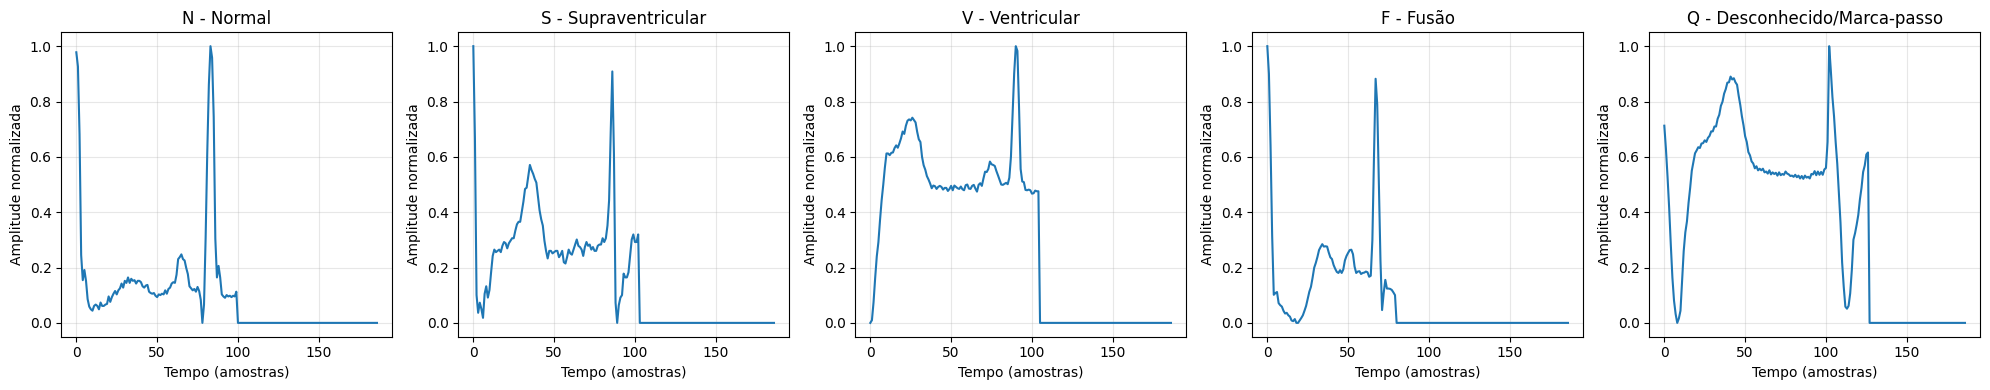

In [4]:
# Para visualizar graficamente os dados precisamos utilizar a biblioteca de geração gráfica matplotlib
import matplotlib.pyplot as plt


# Criamos um dicionário para tornar a visualização de cada classe mais intuitiva na leitura:
identifica_classes = {
    0: "N - Normal",
    1: "S - Supraventricular",
    2: "V - Ventricular",
    3: "F - Fusão",
    4: "Q - Desconhecido/Marca-passo"
}


# A função abaixo irá criar uma figura principal com 5 subgráficos (um para cada classe):
fig, axes = plt.subplots(1, 5, figsize=(20,4))

for classe, ax in zip(range(5), axes):
    exemplo = base_treino[base_treino[187] == classe].iloc[0, :187]
    ax.plot(exemplo.values)
    ax.set_title(identifica_classes[classe])
    ax.set_xlabel("Tempo (amostras)")
    ax.set_ylabel("Amplitude normalizada")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Agora com o gráfico conseguimos visualizar e confirmar o que o método **.describe()** nos havia indicado anteriormente. Com as visualizações conseguimos ver ainda que a partir de um determinado tempo (por exemplo, após t=100 no gráfico de classe Normal) há a ocorrência do **zero padding**, mas por que isso acontece? Bom, na prática os batimentos reais não vão ter todos a mesma duração (um coração batendo mais rápido terá os batimentos mais curtos, enquanto que o coração batendo mais devagar terá os batimentos mais longos), no entanto para tratamento de dados em Machine Learning uma premissa é que as colunas possuam todas a mesma quantidade de informações. Por este motivo, os autores do dataset optaram pelo padding de preenchimento dos espaços faltantes com o valor 0 até completar 187.

No início deste documento foi citado que uma das limitações deste dataset é o alto desbalanceamento entre as classes existentes, o que pode afetar as métricas utilizadas para avaliação e treinamento dos modelos. Podemos ver visualmente o desbalanceamento citado por meio de um pequeno trecho de código, conforme abaixo:

#-------------------- DISTRIBUIÇÃO DAS CLASSES (BASE DE TREINO) --------------------#
                      Classe  Quantidade  Percentual (%)
                  N - Normal       72471           82.77
        S - Supraventricular        2223            2.54
             V - Ventricular        5788            6.61
                   F - Fusão         641            0.73
Q - Desconhecido/Marca-passo        6431            7.35
#----------------------------------------------------------------------------------#

#-------------------- DISTRIBUIÇÃO DAS CLASSES (BASE DE TESTE) --------------------#
                      Classe  Quantidade  Percentual (%)
                  N - Normal       18118           82.76
        S - Supraventricular         556            2.54
             V - Ventricular        1448            6.61
                   F - Fusão         162            0.74
Q - Desconhecido/Marca-passo        1608            7.35
#----------------------------------------------------------

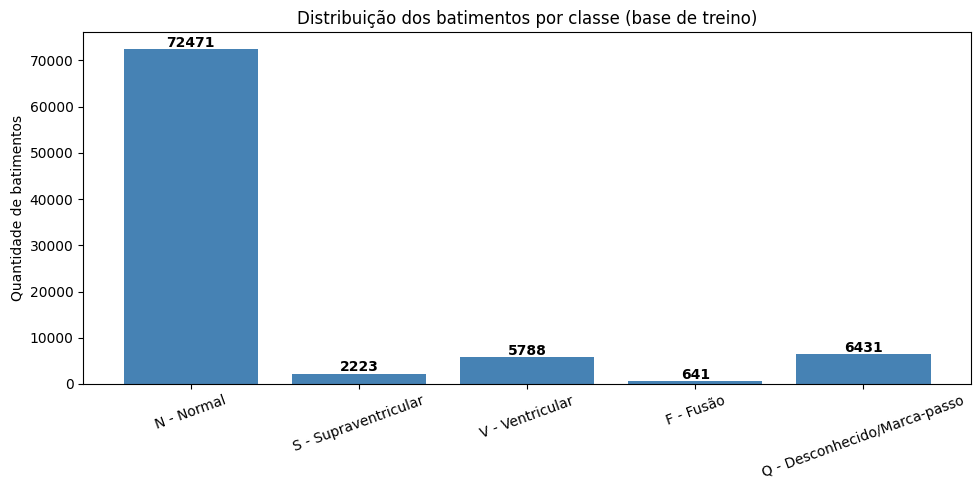

In [5]:
contagem_treino = base_treino[187].value_counts().sort_index()
contagem_teste  = base_teste[187].value_counts().sort_index()
percentual_treino = base_treino[187].value_counts(normalize=True).sort_index() * 100
percentual_teste =  base_teste[187].value_counts(normalize=True).sort_index() * 100

resumo_treino = DataFrame({
    "Classe" : [identifica_classes[c] for c in contagem_treino.index],
    "Quantidade" : contagem_treino.values,
    "Percentual (%)" : percentual_treino.values.round(2)
})
resumo_teste = DataFrame({
    "Classe" : [identifica_classes[c] for c in contagem_teste.index],
    "Quantidade" : contagem_teste.values,
    "Percentual (%)" : percentual_teste.values.round(2)
})

print("#-------------------- DISTRIBUIÇÃO DAS CLASSES (BASE DE TREINO) --------------------#")
print(resumo_treino.to_string(index=False))
print("#----------------------------------------------------------------------------------#\n")

print("#-------------------- DISTRIBUIÇÃO DAS CLASSES (BASE DE TESTE) --------------------#")
print(resumo_teste.to_string(index=False))
print("#----------------------------------------------------------------------------------#\n")

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10,5))
ax.bar([identifica_classes[c] for c in contagem_treino.index], contagem_treino.values, color="steelblue")
ax.set_title("Distribuição dos batimentos por classe (base de treino)")
ax.set_ylabel("Quantidade de batimentos")
ax.tick_params(axis='x', rotation=20)

# Adiciona o número em cima da barra
for i, v in enumerate(contagem_treino.values):
    ax.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


Os resultados anteriores confirmam o desbalanceamento onde conseguimos ver tanto na base de treino quanto na base de teste que a classe normal concentra praticamente 82,8% dos batimentos, enquanto a classe fusão fica próxima de apenas 0,75% dos batimentos. Esta é uma diferença gigantesca entre a classe mais frequente e a menos frequente, e que pode implicar diretamente em avaliações futuras, mas por que?

- Se quase 83% dos dados são de classe Normal, se o modelo prever normal para todas as entradas sua acurácia ainda seria de 83%, sem nunca sequer ter identificado uma anomalia de batimento.
- Classes como Fusão e Supraventricular possuem pouquíssimos registros, o que torna maior a dificuldade de aprendizagem do modelo, necessitando de balanceamento e/ou ponderamento das classes durante esta etapa.

Nas próximas etapas de modelagem veremos como iremos tratar essas implicações.  

#### **3.2 Preparação dos Dados**

A partir de agora revisaremos alguns conceitos sobre a preparação dos dados:

- Valores Ausentes: Como vimos anteriormente, não há valores ausentes em nenhuma das bases pois o princípio de zero padding já foi aplicado na concepção do DataSet (tanto para a base de treino como para a base de teste). Portanto, **não será necessária aplicação de técnicas para tratamento** dos registros.  

- Outliers: Esse termo refere-se a medições que destoam muito do padrão geral dos dados. Imagine por exemplo que estamos medindo a altura de 10 pessoas adultas, e dentro dessas medidas um valor foi registrado como 9,90m. Isso trata de um outlier gigante, pois nenhum ser humano é capaz de ter esse tamanho. No entanto, como o dataset selecionado é referente a medição de um sinal cardíaco o tratamento tem que ser relativo (sinais cardíacos costumam apresentar valores de pico muito diferentes da média dos valores, justamente representando momentos distintos do batimento). Dessa forma, o tratamento dos outliers não pode ser feito simplesmente com a remoção de valores extremos, pois isso impactaria diretamente na detecção de arritmias e anomalias de batimentos; sendo assim, optou-se neste trabalho pela **não remoção dos outliers**.

- Codificação de Variáveis Categóricas: Quando falamos de codificação de variáveis categóricas nos referimos a necessidade de se adaptar um valor em texto para forma numeral, pois os modelos são capazes apenas da interpretação numérica. No caso do dataset selecionado, **não há variáveis categóricas** entre os atributos, pois todas as colunas existentes do sinal já são numéricas (do tipo float). A relação entre valor numéricos e descrição da classe pode ser vista na tabela apresentada no capítulo 2 deste trabalho.

- Normalização: Tem como objetivo principal estabelecer um intervalo fixo (tipicamente seleciona-se entre [0,1]) de forma que os valores estejam todos de uma mesma escala para se realizar comparações e análises. Novamente, em virtude do dataset selecionado, **o sinal cardíaco já está normalizado no dataset**, e os gráficos gerados anteriormente mostram o seu intervalo de variação. Caso fosse necessário realizar alguma transformação na escala, o ajuste seria feito apenas sobre os dados da base de treino, de forma a evitar o vazamento de dados (data leakage) para o conjunto de teste.

- Séries Temporais: O ECG é uma série temporal, pois cada batimento é referente a um sinal ao longo do tempo. No entanto, o **dataset já foi pré-processado**, os autores segmentaram o sinal contínuo em batimentos individuais, e os alinharam pela medição de pico, normalizando e padronizando o comprimento (com o zero padding).  

- Engenharia de Atributos: Nesta etapa decide-se sobre a necessidade da criação de novos atributos a partir dos existentes para ajuste do modelo. Para este dataset uma possível aplicação seria a extração de um conjunto de características interpretáveis como (pico do sinal, duração do sinal, entre outras) e as utilizar no lugar do sinal bruto. No entanto, **optou-se pela utilização dos sinais brutos** por completo, pois os modelos lidam bem com os padrões, e a adição de novos atributos acrescentaria complexidade e poderia ser uma fonte de erro nova a modelagem. Além disso, manter o sinal por completo preserva toda informação morfológica do batimento, evitando a perda que ocorreria ao resumi-lo em outro conjunto de medidas.

- Seleção ou Remoção de Atributos: Para manter-se a coerência com a escolha em relação a engenharia de atributos, também não se optou pela seleção ou remoção de atributos existentes, pelo simples fato das 187 colunas não serem atributos independentes, mas sim pontos sequenciais de um mesmo sinal. A remoção de colunas individuais poderia apagar pedaços do meio de uma onda, o que destruiria a natureza que o modelo precisa interpretar.

- Pipelines: Trata de uma forma de se "encadear" etapas de pré-processamento e o modelo em um único objeto. Ao invés se aplicar as transformações soltas, monta-se uma sequência em passos. Ele será abordado diretamente no capítulo referente a modelagem de dados.  

- Validação Cruzada: É o conceito de divisão do treino em k pedaços (5 por exemplo, sendo 4 para treino e 1 para validação), rodando k vezes e alternando, retirando a média ao final. O dataset selecionado possui em torno de 87 mil batimentos na base de treino, e os modelos podem ficar bem lentos para etapa de treinamento. Dessa forma, **optou-se pela utilização de validação cruzada na etapa de otimização de hiperparâmetros**.

### **4. Modelagem e Treinamento**

#### **4.1 Separação de Atributos (X) e Variável Target (Y)**

As colunas de 0 a 186 correspondem ao sinal do batimento (os atributos) e a coluna 187 corresponde a classe target. Essa separação foi feita na concepção do dataset.

In [ ]:
# Separação entre atributos (X) e variável target (Y)
# Colunas 0 a 186 -> sinais atributos
# Coluna 187 -> variável target
X_treino = base_treino.iloc[:, :-1]
Y_treino = base_treino.iloc[:, -1]
X_teste  = base_teste.iloc[:, :-1]
Y_teste  = base_teste.iloc[:, -1]


# Confirmação dos formatos
print("#-------------------- SEPARAÇÃO X / y --------------------#")
print(f"X_treino: {X_treino.shape}  |  y_treino: {Y_treino.shape}")
print(f"X_teste:  {X_teste.shape}   |  y_teste:  {Y_teste.shape}")
print("#---------------------------------------------------------#")

#-------------------- SEPARAÇÃO X / y --------------------#
X_treino: (87554, 187)  |  y_treino: (87554,)
X_teste:  (21892, 187)   |  y_teste:  (21892,)
#---------------------------------------------------------#


Conforme foi discutido na etapa de preparação, o dataset já se encontra em formato adequado para modelagem, isto é, sem valores ausentes, sem variáveis categóricas e com o sinal já normalizado dentro do intervalo [0,1]. Por este motivo, não foi necessária uma etapa de pré-processamento de escala (como padronização adicional) já que os atributos compartilham a mesma natureza e escala. O pré-processamento irá se concentrar então no tratamento do desbalanceamento entre as classes.

In [1]:
%pip install -q imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Aqui são importados os cinco modelos escolhidos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Tratamento do balanceamento
# foi utilizado imbalanced-learn pois ele aplica SMOTE apenas na base de treino, pulando a de teste.
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Métricas de avaliação
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


#### **4.2 Função Auxiliar de Treinamento e Avaliação**

Como serão comparados cinco modelos que seguem o mesmo fluxo de processamento (aplicação de balanceamento, treinamento e avaliação), optou-se por se utilizar uma função geral. Dessa forma, evita-se repetição de códigos, reduz a chance de erros e ajuda-se a manter uma boa organização. Essa função tem como objetivo montar uma **pipeline** da biblioteca `imbalanced-learn` que encadeia somente o SMOTE ao modelo. Essa é uma etapa muito importante para evitar o vazamento de dados, e o SMOTE será aplicado somente na base de treino, gerando exemplos sintéticos. Para cada modelo de função irá retornar:

- F1-score (versão macro e ponderada).
- Acurácia.
- Tempo de treinamento.

In [2]:
import time

SEED = 42  #aleatoriedade interna (fixa a mesma aleatoriedade a cada teste)

def treino_e_avaliacao(nome,modelo,X_treino,Y_treino,X_teste,Y_teste,usar_smote=True):
    # Nome: rótulo do modelo, para identificação dos resultados.
    # Modelo: Classificador instanciado.
    # usar_smote: Quando TRUE, aplica-se somente na base de treino.
    if usar_smote:
        pipe = Pipeline(steps=[
            ("smote", SMOTE(random_state=SEED)),
            ("modelo", modelo)
        ])
    else:
        pipe = Pipeline(steps=[("modelo", modelo)])

    # Treinamento e medicao de tempo
    inicio = time.time()
    pipe.fit(X_treino, Y_treino)
    tempo_treino = time.time() - inicio

    # Previsão na base de testes (não utiliza o SMOTE aqui)
    Y_pred = pipe.predict(X_teste)

    # Métricas de avaliação:
    resultado = {
        "Modelo": nome,
        "Acurácia" : accuracy_score(Y_teste, Y_pred),
        "F1 Macro" : f1_score(Y_teste, Y_pred, average="macro"),
        "F1 Ponderada" : f1_score(Y_teste, Y_pred, average="weighted"),
        "Tempo (segundos)" : round(tempo_treino, 2)
    }

    return resultado, pipe

#### **4.3 Criação dos Modelos**

Para cada modelo que será treinado pela função definida na seção anterior, será incluida uma chave em um dicionário onde cada item representa "nome -> modelo". Como o SMOTE não faz sentido para o baseline ele precisa de uma declaração `usar_smote = False`.

In [3]:
# Criação de dicionário com os 5 modelos definidos
modelos = {
    "Baseline (DummyClassifier)" :  (DummyClassifier(strategy="most_frequent", random_state=SEED), False),
    "Regressão Logística" :         (LogisticRegression(max_iter=1000, random_state=SEED), True),
    "Random Forest" :               (RandomForestClassifier(random_state=SEED), True),
    "KNN" :                         (KNeighborsClassifier(), True),
    "HistGradientBoosting" :        (HistGradientBoostingClassifier(random_state=SEED), True),
}

print(f"Modelos definidos: {len(modelos)}")
for nome in modelos:
    print(f" - {nome}")

Modelos definidos: 5
 - Baseline (DummyClassifier)
 - Regressão Logística
 - Random Forest
 - KNN
 - HistGradientBoosting


In [ ]:
# Lista para salvar os resultados dos modelos
resultados = []
modelos_treinados = {}

print("Treinando e avaliando os modelos...\n")

# Percorre, pelo dicionario, cada modelo:
for nome, (modelo,usar_smote) in modelos.items():
    print(f" -> {nome} ...", end=" ")
    resultado, pipe = treino_e_avaliacao(
        nome,modelo,X_treino,Y_treino,X_teste,Y_teste,usar_smote=usar_smote
    )
    resultados.append(resultado)
    modelos_treinados[nome] = pipe
    print(f"concluído em ({resultado['Tempo (segundos)']} segundos)")

# Print de tabela comparativada entre os modelos
tabela_resultados = DataFrame(resultados)
print("\n#-------------------- COMPARAÇÃO DOS MODELOS --------------------#")
print(tabela_resultados.to_string(index=False))
print("#----------------------------------------------------------------#")